# Movie Recommendation System
## Comparison between CountVectorizer and TF-IDF

In this notebook, we compare two vectorization methods for a content-based movie recommendation system:

- **CountVectorizer**
- **TfidfVectorizer**

The objective is to see which method produces more relevant recommendations based on movie metadata such as genres, director, and actors.

In [14]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [15]:
data = pd.read_csv("data.csv")
data.head()

,actor_1_name,actor_2_name,actor_3_name,director_name,genres,movie_title,comb
0,CCH Pounder,Joel David Moore,Wes Studi,James Cameron,Action|Adventure|Fantasy|Sci-Fi,avatar,CCH Pounder Joel David Moore Wes Studi James C...
1,Johnny Depp,Orlando Bloom,Jack Davenport,Gore Verbinski,Action|Adventure|Fantasy,pirates of the caribbean: at world's end,Johnny Depp Orlando Bloom Jack Davenport Gore ...
2,Christoph Waltz,Rory Kinnear,Stephanie Sigman,Sam Mendes,Action|Adventure|Thriller,spectre,Christoph Waltz Rory Kinnear Stephanie Sigman ...
3,Tom Hardy,Christian Bale,Joseph Gordon-Levitt,Christopher Nolan,Action|Thriller,the dark knight rises,Tom Hardy Christian Bale Joseph Gordon-Levitt ...
4,Doug Walker,Rob Walker,unknown,Doug Walker,Documentary,star wars: episode vii - the force awakens ...,Doug Walker Rob Walker unknown Doug Walker Doc...


In [16]:
print("Shape of dataset:", data.shape)
print("\nColumns:")
print(data.columns.tolist())

Shape of dataset: (5043, 7)

Columns:
['actor_1_name', 'actor_2_name', 'actor_3_name', 'director_name', 'genres', 'movie_title', 'comb']


In [17]:
data = data.fillna("")
data['movie_title'] = data['movie_title'].astype(str).str.lower()

data['comb_weighted'] = (
    data['genres'].astype(str) + ' ' +
    data['genres'].astype(str) + ' ' +
    data['genres'].astype(str) + ' ' +
    data['director_name'].astype(str) + ' ' +
    data['director_name'].astype(str) + ' ' +
    data['actor_1_name'].astype(str) + ' ' +
    data['actor_2_name'].astype(str) + ' ' +
    data['actor_3_name'].astype(str)
)

In [18]:
import matplotlib.pyplot as plt

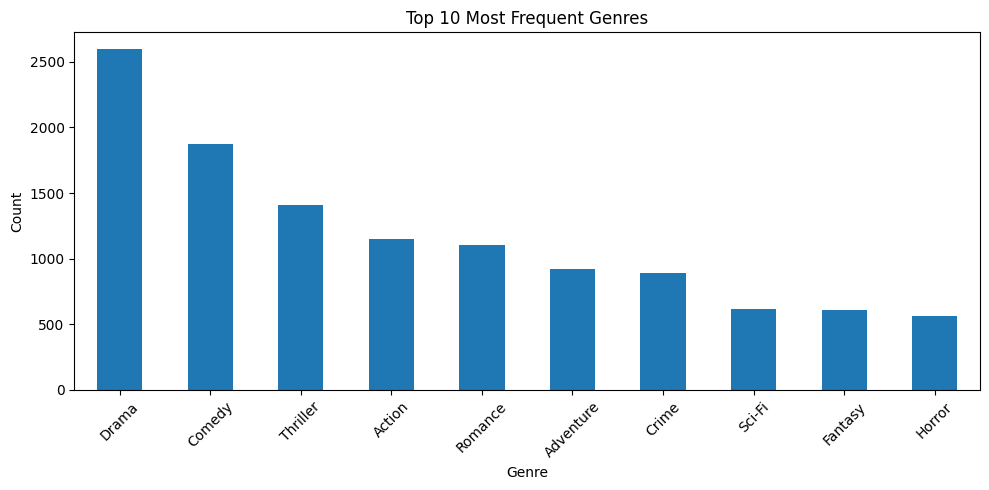

In [19]:
genre_series = data['genres'].str.split('|').explode()
genre_counts = genre_series.value_counts().head(10)

plt.figure(figsize=(10, 5))
genre_counts.plot(kind='bar')
plt.title("Top 10 Most Frequent Genres")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

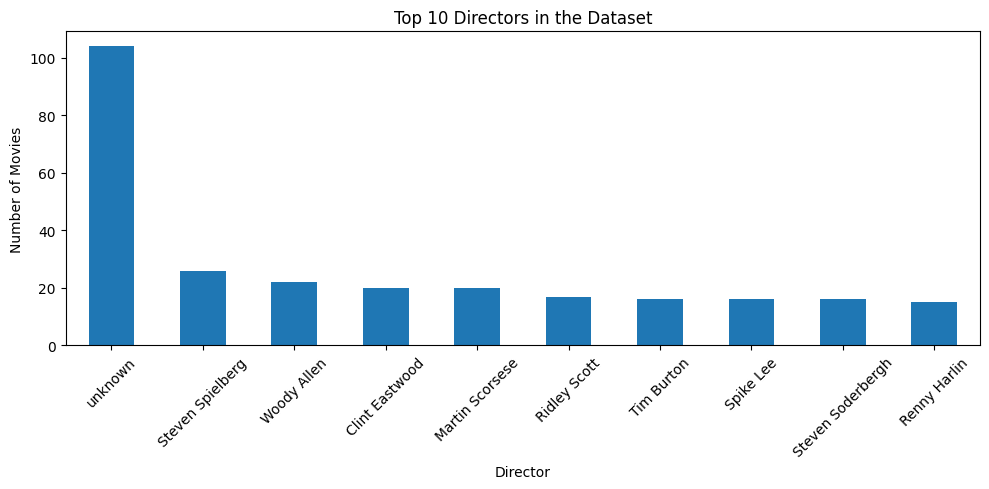

In [20]:
director_counts = data['director_name'].replace('', np.nan).dropna().value_counts().head(10)

plt.figure(figsize=(10, 5))
director_counts.plot(kind='bar')
plt.title("Top 10 Directors in the Dataset")
plt.xlabel("Director")
plt.ylabel("Number of Movies")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

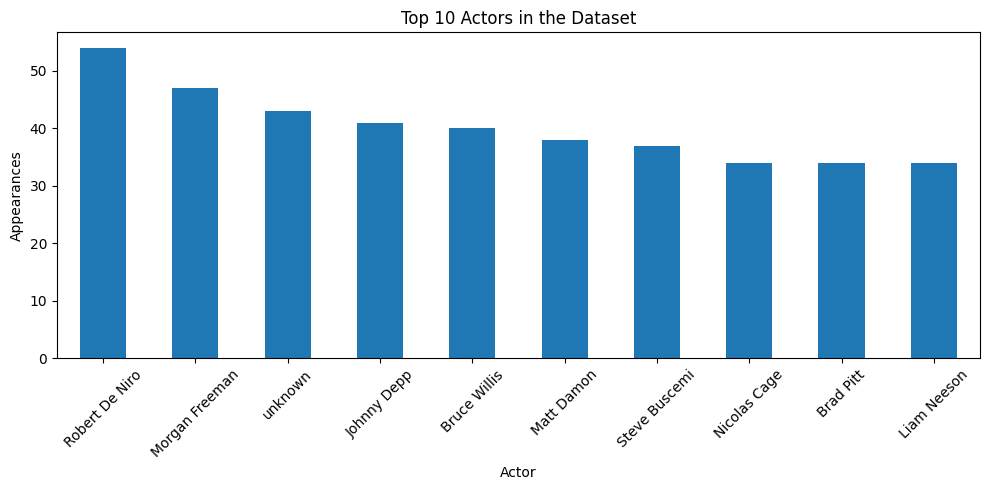

In [21]:
actors = pd.concat([
    data['actor_1_name'],
    data['actor_2_name'],
    data['actor_3_name']
])

actor_counts = actors.replace('', np.nan).dropna().value_counts().head(10)

plt.figure(figsize=(10, 5))
actor_counts.plot(kind='bar')
plt.title("Top 10 Actors in the Dataset")
plt.xlabel("Actor")
plt.ylabel("Appearances")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [22]:
## Recommendation Function This function computes top movie recommendations using a chosen vectorizer.

def recommend_with_vectorizer(movie_name, vectorizer, top_n=10):
    movie_name = movie_name.lower().strip()

    matrix = vectorizer.fit_transform(data['comb_weighted'])
    sim = cosine_similarity(matrix)

    if movie_name not in data['movie_title'].values:
        return pd.DataFrame({"Recommendation": ["Movie not found"], "Similarity Score": ["-"]})

    idx = data[data['movie_title'] == movie_name].index[0]
    scores = list(enumerate(sim[idx]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)[1:top_n+1]

    recommendations = []
    for i, score in scores:
        recommendations.append({
            "Recommendation": data.iloc[i]['movie_title'].title(),
            "Similarity Score": round(score, 4)
        })

    return pd.DataFrame(recommendations)

In [23]:
def compare_results(movie_name):
    count_df = recommend_with_vectorizer(movie_name, CountVectorizer())
    tfidf_df = recommend_with_vectorizer(movie_name, TfidfVectorizer())

    comparison = pd.DataFrame({
        "CountVectorizer": count_df["Recommendation"],
        "Count Score": count_df["Similarity Score"],
        "TF-IDF": tfidf_df["Recommendation"],
        "TF-IDF Score": tfidf_df["Similarity Score"]
    })

    return comparison

In [24]:
compare_results("titanic")

,CountVectorizer,Count Score,TF-IDF,TF-IDF Score
0,Revolutionary Road,0.6875,Revolutionary Road,0.3945
1,The Immigrant,0.6875,Aloha,0.3751
2,The Remains Of The Day,0.6875,Aloha,0.3751
3,Two Lovers,0.6875,Elizabethtown,0.3613
4,Howards End,0.6875,True Lies,0.3581
5,A Room With A View,0.6875,The Abyss,0.3510
6,Maurice,0.6875,The Terminator,0.3483
7,The City Of Your Final Destination,0.6770,Shortbus,0.3322
8,The Great Gatsby,0.6250,Jerry Maguire,0.3283
9,Eat Pray Love,0.6250,Terminator 2: Judgment Day,0.3209


In [25]:
compare_results("avatar")

,CountVectorizer,Count Score,TF-IDF,TF-IDF Score
0,Aliens,0.8033,Aliens,0.5861
1,The Amazing Spider-Man 2,0.7628,The Terminator,0.5783
2,Dragonball: Evolution,0.7615,Terminator 2: Judgment Day,0.5328
3,Man Of Steel,0.7563,The Abyss,0.5320
4,Star Wars: Episode Iii - Revenge Of The Sith,0.7563,Star Wars: The Clone Wars,0.4641
5,Star Wars: Episode Ii - Attack Of The Clones,0.7563,Dragonball: Evolution,0.4607
6,Star Wars: Episode I - The Phantom Menace,0.7563,Stargate: The Ark Of Truth,0.4396
7,The League Of Extraordinary Gentlemen,0.7563,Star Wars: Episode Iii - Revenge Of The Sith,0.4379
8,Star Wars: Episode Vi - Return Of The Jedi,0.7563,Star Wars: Episode Ii - Attack Of The Clones,0.4379
9,Star Wars: Episode V - The Empire Strikes Back,0.7563,Star Wars: Episode Iv - A New Hope,0.4307


In [26]:
movie_test = "avatar"

count_avatar = recommend_with_vectorizer(movie_test, CountVectorizer())
tfidf_avatar = recommend_with_vectorizer(movie_test, TfidfVectorizer())

print("CountVectorizer recommendations:")
print(count_avatar)

print("\nTF-IDF recommendations:")
print(tfidf_avatar)

CountVectorizer recommendations:
                                   Recommendation  Similarity Score
0                                          Aliens            0.8033
1                        The Amazing Spider-Man 2            0.7628
2                           Dragonball: Evolution            0.7615
3                                    Man Of Steel            0.7563
4    Star Wars: Episode Iii - Revenge Of The Sith            0.7563
5    Star Wars: Episode Ii - Attack Of The Clones            0.7563
6       Star Wars: Episode I - The Phantom Menace            0.7563
7           The League Of Extraordinary Gentlemen            0.7563
8      Star Wars: Episode Vi - Return Of The Jedi            0.7563
9  Star Wars: Episode V - The Empire Strikes Back            0.7563

TF-IDF recommendations:
                                 Recommendation  Similarity Score
0                                        Aliens            0.5861
1                                The Terminator            0.5

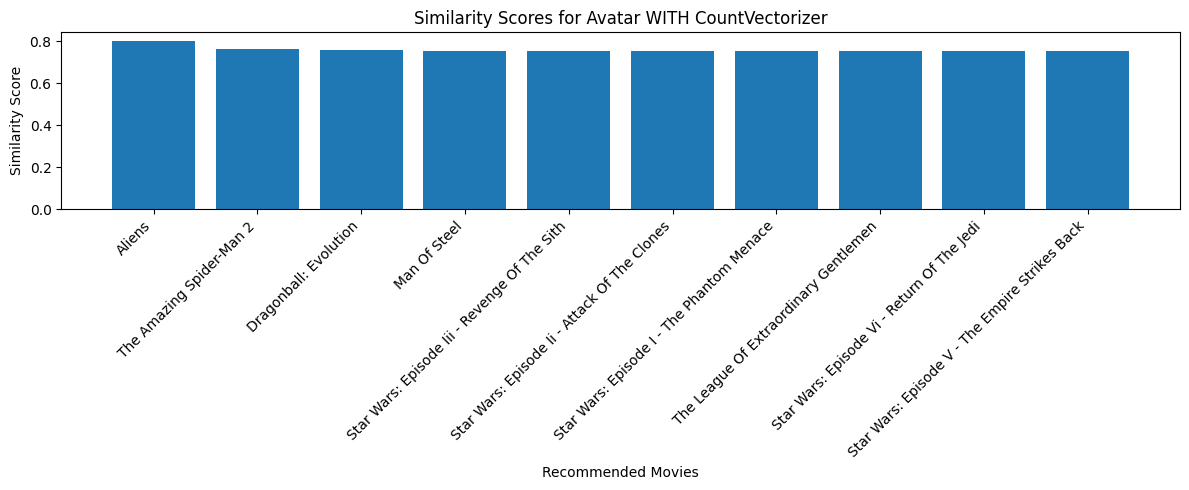

In [28]:
plt.figure(figsize=(12, 5))
plt.bar(count_avatar["Recommendation"], count_avatar["Similarity Score"])
plt.title("Similarity Scores for Avatar WITH CountVectorizer")
plt.xlabel("Recommended Movies")
plt.ylabel("Similarity Score")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

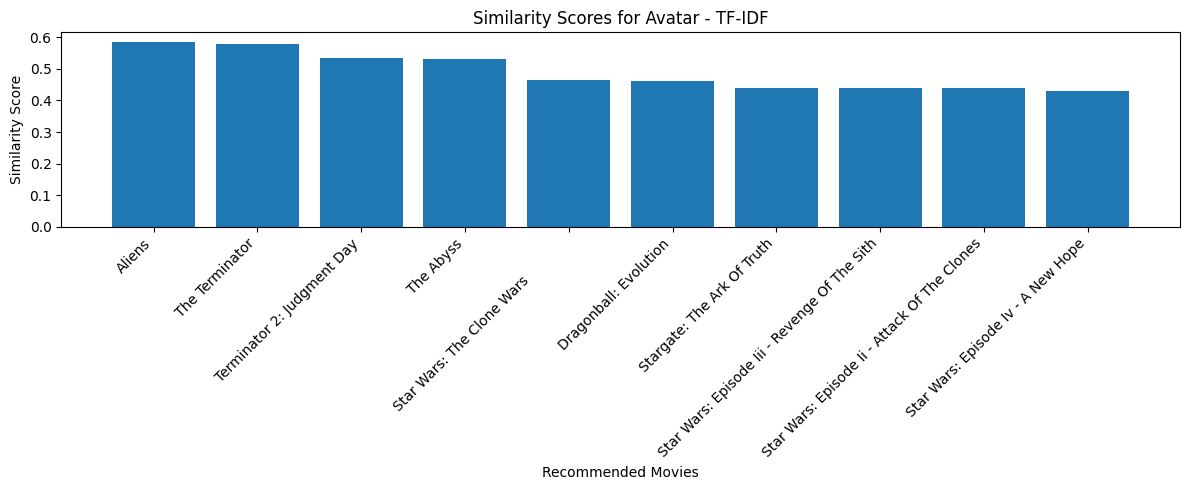

In [29]:
plt.figure(figsize=(12, 5))
plt.bar(tfidf_avatar["Recommendation"], tfidf_avatar["Similarity Score"])
plt.title("Similarity Scores for Avatar - TF-IDF")
plt.xlabel("Recommended Movies")
plt.ylabel("Similarity Score")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [31]:
test_movies = ["avatar", "titanic", "the dark knight", "interstellar"]

avg_count_scores = []
avg_tfidf_scores = []

for movie in test_movies:
    count_df = recommend_with_vectorizer(movie, CountVectorizer())
    tfidf_df = recommend_with_vectorizer(movie, TfidfVectorizer())

    avg_count_scores.append(count_df["Similarity Score"].mean())
    avg_tfidf_scores.append(tfidf_df["Similarity Score"].mean())

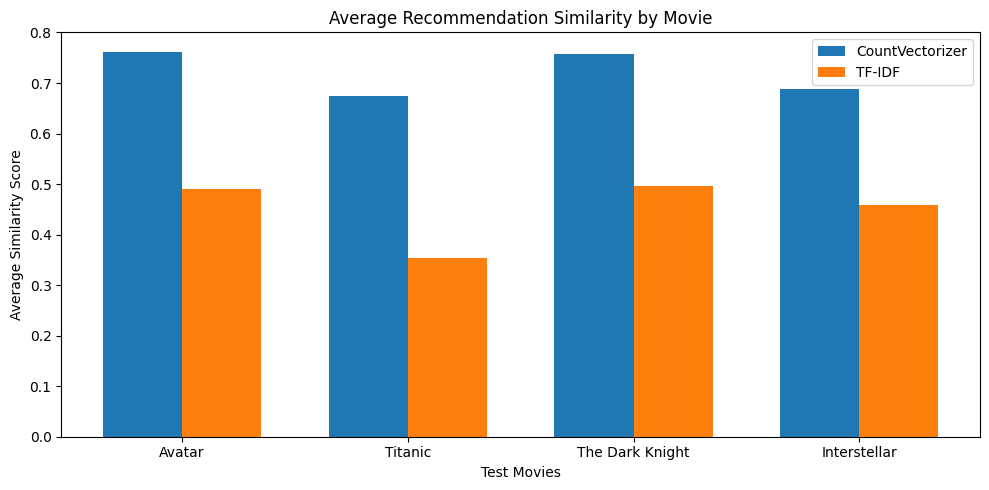

In [32]:
x = np.arange(len(test_movies))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, avg_count_scores, width=width, label="CountVectorizer")
plt.bar(x + width/2, avg_tfidf_scores, width=width, label="TF-IDF")

plt.title("Average Recommendation Similarity by Movie")
plt.xlabel("Test Movies")
plt.ylabel("Average Similarity Score")
plt.xticks(x, [movie.title() for movie in test_movies])
plt.legend()
plt.tight_layout()
plt.show()

## Conclusion

We improved the recommendation system by:
- replacing CountVectorizer with TfidfVectorizer
- applying feature weighting:
  - genres repeated 3 times
  - director repeated 2 times
  - actors repeated 1 time

These changes make the recommendations more coherent and better aligned with movie metadata similarity.